<br><h1 style='text-align: center;'>Fake News</h1><br>
# Part 1 - Data Processing
### Task 1 - Small sample

In [13]:
#!uv add polars numpy matplotlib seaborn nltk

In [14]:
import polars as pl
import matplotlib.pyplot as plt
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

plt.style.use("ggplot")

In [15]:
_filepath = "./data/news_sample.csv"
df = pl.read_csv(_filepath).drop([""])  # drop the unnamed first column
# Read data
df

id,domain,type,url,content,scraped_at,inserted_at,updated_at,title,authors,keywords,meta_keywords,meta_description,tags,summary
i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str
141,"""awm.com""","""unreliable""","""http://awm.com/church-congrega…","""Sometimes the power of Christm…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Church Congregation Brings Gif…","""Ruth Harris""",null,"""['']""",null,null,null
256,"""beforeitsnews.com""","""fake""","""http://beforeitsnews.com/awake…","""AWAKENING OF 12 STRANDS of DNA…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""AWAKENING OF 12 STRANDS of DNA…","""Zurich Times""",null,"""['']""",null,null,null
700,"""cnnnext.com""","""unreliable""","""http://www.cnnnext.com/video/1…","""Never Hike Alone: A Friday the…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Never Hike Alone - A Friday th…",null,null,"""['']""","""Never Hike Alone: A Friday the…",null,null
768,"""awm.com""","""unreliable""","""http://awm.com/elusive-alien-o…","""When a rare shark was caught, …","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Elusive ‘Alien Of The Sea ‘ Ca…","""Alexander Smith""",null,"""['']""",null,null,null
791,"""bipartisanreport.com""","""clickbait""","""http://bipartisanreport.com/20…","""Donald Trump has the unnerving…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Trump’s Genius Poll Is Complet…","""Gloria Christie""",null,"""['']""",null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
39259,"""beforeitsnews.com""","""fake""","""http://beforeitsnews.com/econo…","""Prison for Rahm, God’s Work An…","""2018-01-25 20:13:50.426130""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Prison for Rahm, God’s Work An…",null,null,"""['']""",null,null,null
39468,"""beforeitsnews.com""","""fake""","""http://beforeitsnews.com/diy/2…","""4 Useful Items for Your Tiny H…","""2018-01-25 20:13:50.426130""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""4 Useful Items for Your Tiny H…","""Dimitry K""",null,"""['']""",null,null,null
39477,"""www.newsmax.com""",null,"""https://www.newsmax.com/politi…","""Former CIA Director Michael Ha…","""2018-01-25 20:13:50.426130""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Michael Hayden: We Should Be '…","""Todd Beamon""",null,"""['michael hayden', 'sthole cou…","""President Donald Trump's repor…","""Homeland Security, Trump Admin…",null


In [16]:
print(df.schema)
print(f"Shape: {df.shape}")
print(f"Null counts:\n{df.null_count()}")

Schema({'id': Int64, 'domain': String, 'type': String, 'url': String, 'content': String, 'scraped_at': String, 'inserted_at': String, 'updated_at': String, 'title': String, 'authors': String, 'keywords': String, 'meta_keywords': String, 'meta_description': String, 'tags': String, 'summary': String})
Shape: (250, 15)
Null counts:
shape: (1, 15)
┌─────┬────────┬──────┬─────┬───┬───────────────┬──────────────────┬──────┬─────────┐
│ id  ┆ domain ┆ type ┆ url ┆ … ┆ meta_keywords ┆ meta_description ┆ tags ┆ summary │
│ --- ┆ ---    ┆ ---  ┆ --- ┆   ┆ ---           ┆ ---              ┆ ---  ┆ ---     │
│ u32 ┆ u32    ┆ u32  ┆ u32 ┆   ┆ u32           ┆ u32              ┆ u32  ┆ u32     │
╞═════╪════════╪══════╪═════╪═══╪═══════════════╪══════════════════╪══════╪═════════╡
│ 0   ┆ 0      ┆ 12   ┆ 0   ┆ … ┆ 0             ┆ 196              ┆ 223  ┆ 250     │
└─────┴────────┴──────┴─────┴───┴───────────────┴──────────────────┴──────┴─────────┘


In [17]:
df_1 = (
    df.drop(["keywords", "summary"])
    .fill_null("nan")
    .with_columns(
        pl.when(pl.col("meta_keywords") == "['']")
        .then(pl.lit("nan"))
        .otherwise(pl.col("meta_keywords"))
        .alias("meta_keywords")
    )
)
df_1

id,domain,type,url,content,scraped_at,inserted_at,updated_at,title,authors,meta_keywords,meta_description,tags
i64,str,str,str,str,str,str,str,str,str,str,str,str
141,"""awm.com""","""unreliable""","""http://awm.com/church-congrega…","""Sometimes the power of Christm…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Church Congregation Brings Gif…","""Ruth Harris""","""nan""","""nan""","""nan"""
256,"""beforeitsnews.com""","""fake""","""http://beforeitsnews.com/awake…","""AWAKENING OF 12 STRANDS of DNA…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""AWAKENING OF 12 STRANDS of DNA…","""Zurich Times""","""nan""","""nan""","""nan"""
700,"""cnnnext.com""","""unreliable""","""http://www.cnnnext.com/video/1…","""Never Hike Alone: A Friday the…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Never Hike Alone - A Friday th…","""nan""","""nan""","""Never Hike Alone: A Friday the…","""nan"""
768,"""awm.com""","""unreliable""","""http://awm.com/elusive-alien-o…","""When a rare shark was caught, …","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Elusive ‘Alien Of The Sea ‘ Ca…","""Alexander Smith""","""nan""","""nan""","""nan"""
791,"""bipartisanreport.com""","""clickbait""","""http://bipartisanreport.com/20…","""Donald Trump has the unnerving…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Trump’s Genius Poll Is Complet…","""Gloria Christie""","""nan""","""nan""","""nan"""
…,…,…,…,…,…,…,…,…,…,…,…,…
39259,"""beforeitsnews.com""","""fake""","""http://beforeitsnews.com/econo…","""Prison for Rahm, God’s Work An…","""2018-01-25 20:13:50.426130""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Prison for Rahm, God’s Work An…","""nan""","""nan""","""nan""","""nan"""
39468,"""beforeitsnews.com""","""fake""","""http://beforeitsnews.com/diy/2…","""4 Useful Items for Your Tiny H…","""2018-01-25 20:13:50.426130""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""4 Useful Items for Your Tiny H…","""Dimitry K""","""nan""","""nan""","""nan"""
39477,"""www.newsmax.com""","""nan""","""https://www.newsmax.com/politi…","""Former CIA Director Michael Ha…","""2018-01-25 20:13:50.426130""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Michael Hayden: We Should Be '…","""Todd Beamon""","""['michael hayden', 'sthole cou…","""President Donald Trump's repor…","""Homeland Security, Trump Admin…"


In [18]:
df_1.describe()

statistic,id,domain,type,url,content,scraped_at,inserted_at,updated_at,title,authors,meta_keywords,meta_description,tags
str,f64,str,str,str,str,str,str,str,str,str,str,str,str
"""count""",250.0,"""250""","""250""","""250""","""250""","""250""","""250""","""250""","""250""","""250""","""250""","""250""","""250"""
"""null_count""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0"""
"""mean""",20241.56,null,null,null,null,null,null,null,null,null,null,null,null
"""std""",11515.412728,null,null,null,null,null,null,null,null,null,null,null,null
"""min""",141.0,"""21stcenturywire.com""","""bias""","""http://21stcenturywire.com/201…","""(NaturalNews) If you thought B…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""'Stop Christie' PAC quits, say…","""A Bad Witch'S Blog""","""['', 'Big Government', 'mark l…","""'Enough meddling ... Go home, …","""Achievement Gap, GOP Share Of …"
"""25%""",11001.0,null,null,null,null,null,null,null,null,null,null,null,null
"""50%""",21093.0,null,null,null,null,null,null,null,null,null,null,null,null
"""75%""",29104.0,null,null,null,null,null,null,null,null,null,null,null,null
"""max""",39558.0,"""www.newsmax.com""","""unreliable""","""https://www.undergroundhealth.…","""“Voice or no voice, the people…","""2018-01-25 20:13:50.426130""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""“Draining the Swamp” Doesn’t M…","""nan""","""nan""","""“We are on the precipice of co…","""out of iraq, end the occupatio…"


In [19]:
# Helper function to collect tokens labeled as <OTHER>
def _collect_other(token, log):
    if log is not None:
        log.append(token)
    return "<OTHER>"


# Pattern strings — shared with Task 2 (Polars uses these directly)
email_re = re.compile(r'[^ \n,"]+@[^ \n,"]+\.[^ \n,"]+')
date_re = re.compile(r'[0-9]{2,4}[-/][0-9]{2,4}[-/][0-9]{2,4}')
url_re = re.compile(r'(?:http)?s?(?://)?[^ \n,"]+\.[a-z]{2,}[^ \n,"]+')
num_re = re.compile(r'[0-9]+[,.]?[0-9]*')
special_re = re.compile(r"""[.,/—–!\\"#$%&'()*+:;=?@\[\\\]^_`{|}~€£¥§±×÷°•¶©®™¢∞≠≈≤≥√∑πµω∆∫]""")
ws_re = re.compile(r'\s+')

def clean_text(doc: str):
    lower_case = doc.lower()
    substituted = email_re.sub(" <EMAIL> ", lower_case)
    substituted = date_re.sub(" <DATE> ", substituted)
    substituted = url_re.sub(" <URL> ", substituted)
    substituted = num_re.sub(" <NUM> ", substituted)
    no_specials = special_re.sub(" ", substituted)
    cleaned = ws_re.sub(' ', no_specials).strip()
    return cleaned

<br><br><br>
<h1 style='text-align : center;'>CHECK OTHER</h1>
<br><br><br>

In [20]:
# # Check for most common tokens replaced by <OTHER>
# other_tokens = []
# for doc in df["content"].dropna().head(500):
#     clean_text(doc, other_log=other_tokens)

# # Show most common tokens replaced by <OTHER>
# other_counts = pd.Series(other_tokens).value_counts()[:20]

# print(f"Unique tokens mapped to <OTHER>: {len(other_counts)}")
# other_counts

In [21]:
natural_language_cols = [
    "content",
    "title",
    "authors",
    "meta_keywords",
    "meta_description",
]


def clean(df: pl.DataFrame, nlc: list[str] = natural_language_cols):
    # Given a DataFrame and potentially
    #   1. a list, nlc, of natural language columns (default: "natural_language_cols")
    # Returns new DataFrame with nlc cleaned.
    return df.with_columns(
        [
            pl.col(col)
            .map_elements(lambda x: clean_text(x), return_dtype=pl.String)
            .alias(col)
            for col in nlc
        ]
    )


# df = clean(df)
df_1.filter(pl.col("meta_keywords") != "nan").select(
    natural_language_cols
).head()

content,title,authors,meta_keywords,meta_description
str,str,str,str,str
"""President Trump, right, with R…","""In Calling Out 'Fake News,' Do…","""Hamilton Strategies""","""['fake news', 'donald trump', …","""Stephen E. Strang, author of '…"
"""Subscribe to Canada Free Press…","""Obama and Redistribution of Yo…","""Joseph Harris, Because Without…","""['Conservative News', 'Conserv…","""News, Politics, Editorials, co…"
"""President Trump’s plan to cont…","""Ben Cardin: Trump's new Syria …","""Joel Gehrke""","""['Rex Tillerson', 'ISIS', 'Sen…","""“We are on the precipice of co…"
"""Something is wrong at Newsweek…","""Newsweek 'fact check' denies R…","""Becket Adams""","""['Fake News', 'Clinton Foundat…","""What's the use of fact checkin…"
"""American forces made one of th…","""Byron York: U.S. ran out of am…","""Byron York""","""['ISIS', 'National Security', …","""Of a group of 300 oil tankers …"


In [22]:
def rm_stop_words(df: pl.DataFrame, nlc: list[str] = natural_language_cols):
    #Removes stop words from DataFrame with i/o as for the clean function.
    _stop_words = set(stopwords.words("english"))
    return df.with_columns(
        [
            pl.col(col)
            .map_elements(
                lambda x: " ".join(
                    [w for w in x.split() if w not in _stop_words]
                ),
                return_dtype=pl.String,
            )
            .alias(col)
            for col in nlc
        ]
    )

def stem(df: pl.DataFrame, nlc: list[str] = natural_language_cols):
    #Stems DataFrame with i/o as for the clean function.
    _stemmer = PorterStemmer()
    return df.with_columns(
        [
            pl.col(col)
            .map_elements(
                lambda x: " ".join([_stemmer.stem(w) for w in x.split()]),
                return_dtype=pl.String,
            )
            .alias(col)
            for col in nlc
        ]
    )

def preprocess(
    df: pl.DataFrame, nlc: list[str] = natural_language_cols, progbar=False
):
    # General preprocessing function — faster than combining clean, rm_stop_words, stem.
    _stop_words = set(stopwords.words("english"))
    _stemmer = PorterStemmer()
    return df.with_columns(
        [
            pl.col(col)
            .map_elements(
                lambda x: " ".join(
                    [
                        _stemmer.stem(w)
                        for w in clean_text(x).split()
                        if w not in _stop_words
                    ]
                ),
                return_dtype=pl.String,
            )
            .alias(col)
            for col in nlc
        ]
    )

df_clean = preprocess(df_1)
df_clean.select(natural_language_cols)

content,title,authors,meta_keywords,meta_description
str,str,str,str,str
"""sometim power christma make wi…","""church congreg bring gift wait…","""ruth harri""","""nan""","""nan"""
"""awaken <num> strand dna “recon…","""awaken <num> strand dna “recon…","""zurich time""","""nan""","""nan"""
"""never hike alon friday <num> t…","""never hike alon - friday <num>…","""nan""","""nan""","""never hike alon friday <num> t…"
"""rare shark caught scientist le…","""elus ‘alien sea ‘ caught scien…","""alexand smith""","""nan""","""nan"""
"""donald trump unnerv abil abil …","""trump’ geniu poll complet resu…","""gloria christi""","""nan""","""nan"""
…,…,…,…,…
"""prison rahm god’ work mani oth…","""prison rahm god’ work mani oth…","""nan""","""nan""","""nan"""
"""<num> use item tini home headl…","""<num> use item tini home""","""dimitri k""","""nan""","""nan"""
"""former cia director michael ha…","""michael hayden frighten trump …","""todd beamon""","""michael hayden sthole countri …","""presid donald trump report rem…"


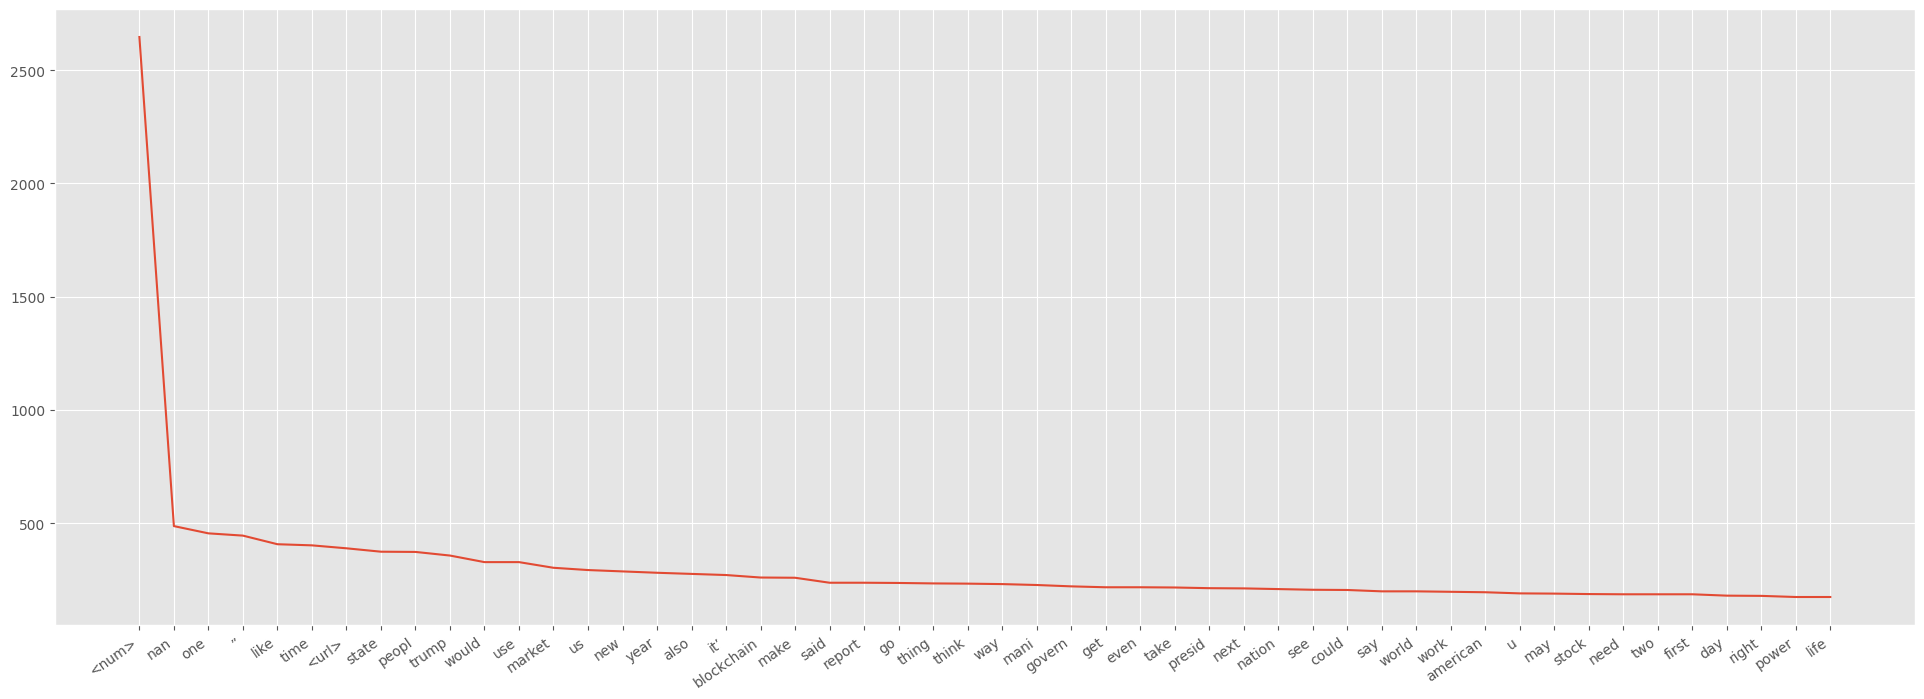

In [23]:
# Make Zipf's law plot of the 50 most common tokens after preprocessing
# Gather all text from NL columns, split into tokens, count
all_text = " ".join(
    df_clean.select(natural_language_cols)
    .fill_null("")
    .unpivot()
    .get_column("value")
    .to_list()
)
from collections import Counter

token_counts = Counter(all_text.split())
most_common = token_counts.most_common(50)
words, counts = zip(*most_common)

plt.figure(figsize=(24, 8))
plt.plot(list(words), list(counts))
plt.xticks(rotation=35, ha="right")
plt.show()

### Task 2 - Bigger subset

In [24]:
import os
import Stemmer  # PyStemmer (~10× faster than NLTK)

#_filepath = "news/data/995,000_rows.csv"
_outpath = "news/data/995,000_rows_preprocessed.csv"
_chunk_size = 50_000

# Preprocess resources (initialized once)
_stop_words = set(stopwords.words("english"))
_stemmer = Stemmer.Stemmer("english")

def _stem_and_filter(x: str) -> str:
    words = [w for w in x.split() if w not in _stop_words]
    return " ".join(_stemmer.stemWords(words))

# Remove old output file if it exists so we can append fresh
if os.path.exists(_outpath):
    os.remove(_outpath)

# Use scan_csv (lazy) and process in chunks to keep memory low
_lf = pl.scan_csv(_filepath)
_total_rows = _lf.select(pl.len()).collect().item()
_n_chunks = (_total_rows + _chunk_size - 1) // _chunk_size
print(
    f"Processing {_total_rows} rows in {_n_chunks} chunks of {_chunk_size}..."
)

for _i in range(_n_chunks):
    _offset = _i * _chunk_size
    # Collect only this chunk from the lazy frame
    _chunk = (
        _lf.slice(_offset, _chunk_size)
        .drop(["id", "Unnamed: 0", "keywords", "summary"])
        .collect()
    )
    # Fill nulls
    _chunk = _chunk.fill_null("nan")
    _chunk = _chunk.with_columns(
        pl.when(pl.col("meta_keywords") == "['']")
        .then(pl.lit("nan"))
        .otherwise(pl.col("meta_keywords"))
        .alias("meta_keywords")
    )
    # --- Regex cleaning via native Polars (runs in Rust, not Python) ---
    _chunk = _chunk.with_columns(
        [
            pl.col(col)
            .str.to_lowercase()
            .str.replace_all(email_pat, " <EMAIL> ")
            .str.replace_all(date_pat, " <DATE> ")
            .str.replace_all(url_pat, " <URL> ")
            .str.replace_all(num_pat, " <NUM> ")
            .str.replace_all(special_pat, " ")
            .str.replace_all(ws_pat, " ")
            .str.strip_chars()
            for col in natural_language_cols
        ]
    )
    # --- Stop-word removal + stemming (PyStemmer is C-based, ~10× faster) ---
    _chunk = _chunk.with_columns(
        [
            pl.col(col)
            .map_elements(_stem_and_filter, return_dtype=pl.String)
            .alias(col)
            for col in natural_language_cols
        ]
    )
    # Write: first chunk with header (creates file), rest append without header
    if _i == 0:
        _chunk.write_csv(_outpath)
    else:
        with open(_outpath, "a") as _f:
            _chunk.write_csv(_f, include_header=False)
    print(
        f"  Chunk {_i + 1}/{_n_chunks} done ({_offset + len(_chunk)} rows so far)"
    )
    del _chunk  # Free memory immediately

print("Done. Preprocessed data saved to", _outpath)

Processing 250 rows in 1 chunks of 50000...


ColumnNotFoundError: "Unnamed: 0" not found

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'sink' <---
SLICE[offset: 0, len: 50000]
  Csv SCAN [./data/news_sample.csv]
  PROJECT */16 COLUMNS
  ESTIMATED ROWS: 377

In [ ]:
df_final = pl.read_csv("./data/995,000_rows_preprocessed.csv")
df_final

domain,type,url,content,scraped_at,inserted_at,updated_at,title,authors,meta_keywords,meta_description,tags,source
str,str,str,str,str,str,str,str,str,str,str,str,str
"""nationalreview.com""","""political""","""http://www.nationalreview.com/…","""plus one articl googl plus tha…","""2017-11-27T01:14:42.983556""","""2018-02-08 19:18:34.468038""","""2018-02-08 19:18:34.468066""","""iran news round""","""nan""","""nation review nation review on…","""nan""","""nan""","""nan"""
"""beforeitsnews.com""","""fake""","""http://beforeitsnews.com/econo…","""cost best senat bank committe …","""2017-11-27T01:14:08.7454""","""2018-02-08 19:18:34.468038""","""2018-02-08 19:18:34.468066""","""cost best senat bank committe …","""nan""","""nan""","""nan""","""nan""","""nan"""
"""dailycurrant.com""","""satire""","""http://dailycurrant.com/2016/0…","""man awoken <NUM> -year coma co…","""2017-11-27T01:14:21.395055""","""2018-02-07 23:39:33.852671""","""2018-02-07 23:39:33.852696""","""man awoken <NUM> -year coma co…","""nan""","""nan""","""nan""","""nan""","""nan"""
"""nytimes.com""","""reliable""","""https://query.nytimes.com/gst/…","""julia geist ask draw pictur co…","""2018-02-11 00:46:42.632962""","""2018-02-11 00:14:20.346838""","""2018-02-11 00:14:20.346871""","""open gateway girl enter comput…","""nan""","""comput internet women girl car…","""julia geist ask draw pictur co…","""nan""","""nytimes"""
"""infiniteunknown.net""","""conspiracy""","""http://www.infiniteunknown.net…","""<NUM> compil studi vaccin dang…","""2017-11-10T11:18:44.524042""","""2018-02-07 23:39:33.852671""","""2018-02-07 23:39:33.852696""","""<NUM> compil studi vaccin dang…","""nan""","""nan""","""nan""","""Lymphoma, Hepatitis B, Immune …","""nan"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""21stcenturywire.com""","""conspiracy""","""http://21stcenturywire.com/tag…","""<NUM> wire intervent watch say…","""2017-11-09T12:48:34.461199""","""2018-02-07 23:39:33.852671""","""2018-02-07 23:39:33.852696""","""koni <NUM> archiv""","""nan""","""nan""","""nan""","""Michelle Obama, Drones, Selfie…","""nan"""
"""nationalreview.com""","""political""","""http://www.nationalreview.com/…","""plus one articl googl plus tha…","""2017-11-27T01:14:42.983556""","""2018-02-08 19:18:34.468038""","""2018-02-08 19:18:34.468066""","""iran news round""","""nan""","""nation review nation review on…","""nan""","""nan""","""nan"""
"""thesaker.is""","""unknown""","""http://thesaker.is/china-and-r…","""china russia acquir gold dump …","""2017-11-18T20:01:27.400599""","""2018-02-07 23:39:33.852671""","""2018-02-07 23:39:33.852696""","""china russia acquir gold dump …","""saker""","""nan""","""bird eye view vineyard""","""Gold, Dollar, Russia, China""","""nan"""
